In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = '/content/drive/MyDrive/dsprites_dataset'

In [ ]:
import os
import numpy as np

npz_path = os.path.join(folder_path, 'dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz')
data = np.load(npz_path, allow_pickle=True)

imgs = data['imgs']
latents_values = data['latents_values']
latents_classes = data['latents_classes']

print(f"✅ Total images: {len(imgs)}")
print(f"✅ Each image shape: {imgs[0].shape}")

✅ Total images: 737280
✅ Each image shape: (64, 64)


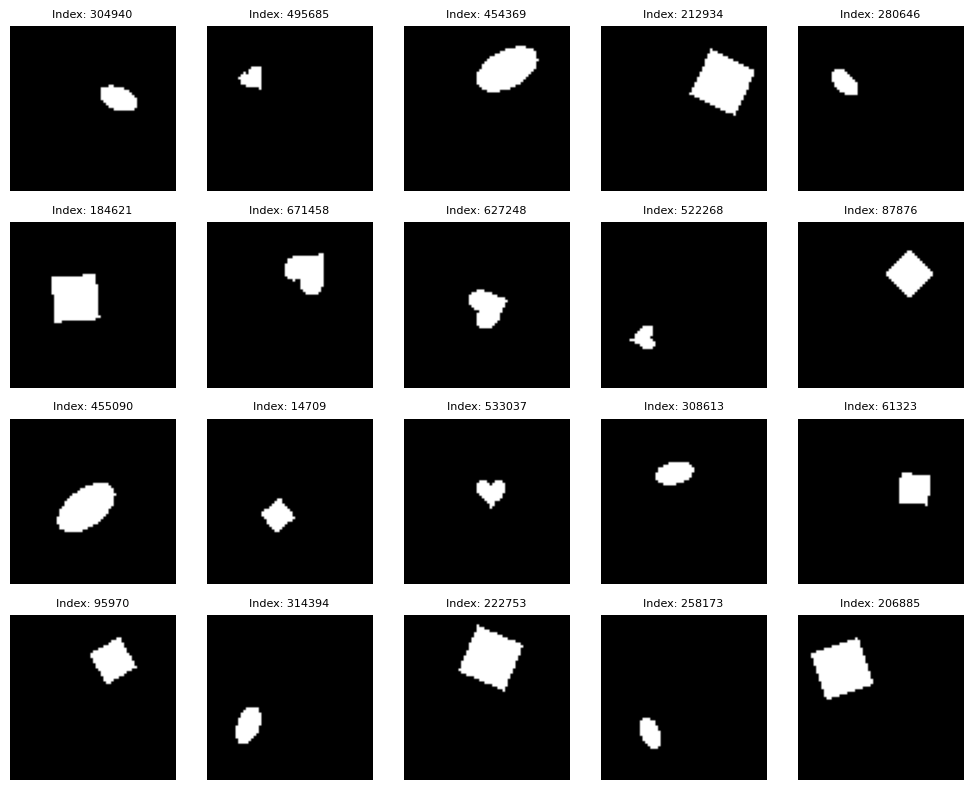

In [ ]:
import matplotlib.pyplot as plt

num_images = 20
random_indices = np.random.choice(len(imgs), num_images, replace=False)

ncols = 5
nrows = int(np.ceil(num_images / ncols))

plt.figure(figsize=(ncols * 2, nrows * 2))
for i, idx in enumerate(random_indices):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(imgs[idx], cmap='gray')
    plt.title(f"Index: {idx}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Hyperparameters from Table 2 ---
EPOCHS = 50
LEARNING_RATE = 0.001
IMAGE_DIM = (64, 64)
BATCH_SIZE = 128

# --- Hyperparameters from Table 1 ---
# h_dim is the latent dimension
LATENT_DIM = 32

# --- Setup device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class DspritesDataset(Dataset):
    def __init__(self, npz_path):
        # Open the .npz file using memory-mapping (mmap_mode='r')
        # This does NOT load the full array into RAM
        try:
            self.data = np.load(npz_path, mmap_mode='r')
            self.imgs = self.data['imgs']
            print(f"Dataset initialized in memory-mapped mode. Total images: {len(self.imgs)}")
        except FileNotFoundError:
            print(f"Error: Dataset file not found at {npz_path}")
            self.imgs = None # Handle error

    def __len__(self):
        if self.imgs is not None:
            return len(self.imgs)
        return 0

    def __getitem__(self, idx):
        if self.imgs is None:
            raise IndexError("Dataset not loaded correctly.")

        # Accessing self.imgs[idx] reads *only* this image from disk
        # 1. Get the single image as a numpy array
        #    We use .copy() because mmapped arrays are read-only
        img = self.imgs[idx].copy()

        # 2. Convert *this single image* to a float tensor
        img_tensor = torch.from_numpy(img).float()

        # 3. Add the channel dimension (H, W) -> (1, H, W)
        img_tensor = img_tensor.unsqueeze(0)

        return img_tensor

In [ ]:
npz_path = os.path.join(folder_path, 'dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz')

# We now pass the *path* to the class, not the loaded array
train_dataset = DspritesDataset(npz_path)

if len(train_dataset) > 0:
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,  # num_workers > 0 speeds up loading
        pin_memory=True # Helps speed up CPU to GPU transfer
    )
    print(f"DataLoader created with batch size: {BATCH_SIZE}")
else:
    print("Failed to initialize DataLoader, dataset is empty or file not found.")

# --- (Your 'if imgs is not None:' checks should be changed) ---
# Check if the dataset loaded correctly before training/evaluating
can_proceed = len(train_dataset) > 0

Dataset initialized in memory-mapped mode. Total images: 737280
DataLoader created with batch size: 128


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()

        # --- Encoder (Table 1) ---
        self.encoder = nn.Sequential(
            # Input: (N, 1, 64, 64)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # (N, 32, 32, 32)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # (N, 64, 16, 16)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (N, 128, 8, 8)
            nn.ReLU(),
            nn.Flatten() # (N, 128 * 8 * 8) = (N, 8192)
        )

        # Latent space layers
        self.fc_mu = nn.Linear(8192, latent_dim)
        self.fc_logvar = nn.Linear(8192, latent_dim)

        # --- Decoder (Table 1) ---
        self.decoder_fc = nn.Linear(latent_dim, 8192)

        self.decoder = nn.Sequential(
            # Input will be (N, 128, 8, 8) after view
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # (N, 64, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # (N, 32, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), # (N, 1, 64, 64)
            nn.Sigmoid() # Final layer is Sigmoid
        )

    # Reparameterization trick (from sub-part 3)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std) # Sample from N(0, 1)
        z = mu + std * epsilon
        return z

    def forward(self, x):
        # Encode
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        # Sample from latent space
        z = self.reparameterize(mu, logvar)

        # Decode
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 128, 8, 8) # Un-flatten
        x_recon = self.decoder(h_recon)

        return x_recon, mu, logvar

In [ ]:
# --- Loss Function (Equation 1) ---
def vae_loss_function(recon_x, x, mu, logvar):
    # 1. Reconstruction Loss (E[log p(x|z)])
    # We use Binary Cross Entropy (BCE) as p(x|z) is Bernoulli (pixel values 0 or 1)
    # We sum it over all pixels
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence (D_KL(q(z|x) || p(z)))
    # Closed-form solution for KL between two Gaussians
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss (Negative ELBO)
    total_loss = BCE + KLD

    return total_loss, BCE, KLD

# --- Initialize Model and Optimizer (Table 2) ---
model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Model and Optimizer initialized.")
print(model)

Model and Optimizer initialized.
VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=8192, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=32, bias=True)
  (decoder_fc): Linear(in_features=32, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [ ]:
# --- Training Loop ---
if imgs is not None:
    # Lists to store loss values for plotting
    epoch_total_losses = []
    epoch_recon_losses = []
    epoch_kl_losses = []

    print("Starting training...")
    model.train() # Set model to training mode

    for epoch in range(EPOCHS):
        # Store losses for this epoch
        total_loss_epoch = 0
        recon_loss_epoch = 0
        kl_loss_epoch = 0

        for batch_idx, data in enumerate(train_loader):
            data = data.to(device)

            # Forward pass
            recon_batch, mu, logvar = model(data)

            # Calculate loss
            total_loss, recon_loss, kl_loss = vae_loss_function(recon_batch, data, mu, logvar)

            # Backward pass and optimization
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            # Accumulate losses
            total_loss_epoch += total_loss.item()
            recon_loss_epoch += recon_loss.item()
            kl_loss_epoch += kl_loss.item()

        # Calculate average losses for the epoch
        avg_total_loss = total_loss_epoch / len(train_dataset)
        avg_recon_loss = recon_loss_epoch / len(train_dataset)
        avg_kl_loss = kl_loss_epoch / len(train_dataset)

        # Store for plotting
        epoch_total_losses.append(avg_total_loss)
        epoch_recon_losses.append(avg_recon_loss)
        epoch_kl_losses.append(avg_kl_loss)

        print(f'Epoch {epoch+1}/{EPOCHS} | Total Loss: {avg_total_loss:.4f} | Recon Loss: {avg_recon_loss:.4f} | KL Loss: {avg_kl_loss:.4f}')

    print("Training finished.")
else:
    print("Cannot start training, data not loaded.")

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 

In [ ]:
save_folder = '/content/drive/MyDrive/DGM_HW1_Results'

# Create the directory if it doesn't exist
if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"Directory created: {save_folder}")
else:
    print(f"Directory already exists: {save_folder}")

# 3. Save the model's state dictionary
# (Assuming your model variable is named 'model')
model_save_path = os.path.join(save_folder, 'vae_model_state_dict.pth')
torch.save(model.state_dict(), model_save_path)
print(f"Model state saved successfully to: {model_save_path}")

# 4. Save the loss history
# (Assuming your lists are named 'epoch_total_losses', 'epoch_recon_losses', 'epoch_kl_losses')
loss_save_path = os.path.join(save_folder, 'vae_loss_history.npz')

# We use np.savez to save multiple arrays in one file
np.savez(loss_save_path,
         total_loss=np.array(epoch_total_losses),
         recon_loss=np.array(epoch_recon_losses),
         kl_loss=np.array(epoch_kl_losses))

print(f"Loss history saved successfully to: {loss_save_path}")

Directory already exists: /content/drive/MyDrive/DGM_HW1_Results
Model state saved successfully to: /content/drive/MyDrive/DGM_HW1_Results/vae_model_state_dict.pth


NameError: name 'epoch_total_losses' is not defined

In [ ]:
# --- 1. Plot Loss Curves ---
if imgs is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(epoch_total_losses, label='Total Loss (Negative ELBO)')
    plt.plot(epoch_recon_losses, label='Reconstruction Loss (BCE)')
    plt.plot(epoch_kl_losses, label='KL Divergence')
    plt.title('VAE Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (per sample)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 2. Show Reconstructions (8 random samples) ---
if imgs is not None:
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        # Get 8 random samples from the dataset
        indices = np.random.randint(0, len(train_dataset), 8)
        sample_images = torch.stack([train_dataset[i] for i in indices]).to(device)

        # Get reconstructions
        recon_images, _, _ = model(sample_images)

        # Move to CPU and numpy for plotting
        sample_images_np = sample_images.cpu().numpy().squeeze()
        recon_images_np = recon_images.cpu().numpy().squeeze()

        # Plot original vs. reconstructed
        fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))

        for i in range(8):
            # Plot original
            axes[0, i].imshow(sample_images_np[i], cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original', loc='left', fontsize=10)

            # Plot reconstructed
            axes[1, i].imshow(recon_images_np[i], cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstructed', loc='left', fontsize=10)

        plt.suptitle('VAE Reconstruction Performance (8 Random Samples)')
        plt.tight_layout()
        plt.show()

#Results

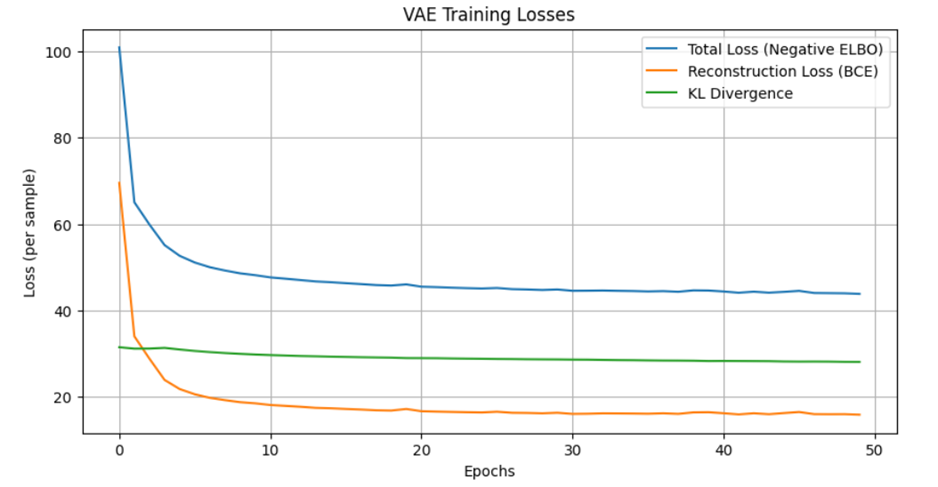



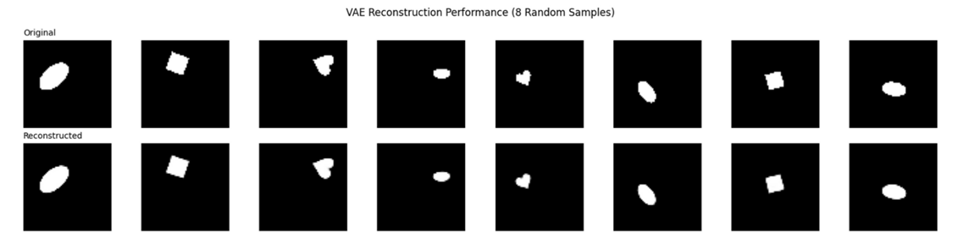

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive')

save_folder = '/content/drive/MyDrive/DGM_HW1_Results/B-VAE'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [ ]:
# New Loss Function
def vae_loss_function_beta(recon_x, x, mu, logvar, beta):
    # 1. Reconstruction Loss (E[log p(x|z)])
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence (D_KL(q(z|x) || p(z)))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # 3. Total loss (Negative ELBO with beta)
    # This is (BCE + beta * KLD)
    total_loss = BCE + beta * KLD

    return total_loss, BCE, KLD

In [ ]:
def train_beta_vae(beta_value, model, optimizer, train_loader, epochs, device, save_folder):

    checkpoint_filename = f"bVAE_beta_{beta_value}_checkpoint.pth"
    checkpoint_path = os.path.join(save_folder, checkpoint_filename)

    start_epoch = 0
    epoch_total_losses = []
    epoch_recon_losses = []
    epoch_kl_losses = []

    # Try to Load from Checkpoint
    if os.path.exists(checkpoint_path):
        print(f"Checkpoint found! Loading from {checkpoint_path}")
        try:
            checkpoint = torch.load(checkpoint_path, map_location=device)

            # Load model and optimizer state
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            # Load training progress
            start_epoch = checkpoint['epoch']
            loss_history = checkpoint['loss_history']
            epoch_total_losses = loss_history['total']
            epoch_recon_losses = loss_history['recon']
            epoch_kl_losses = loss_history['kl']

            print(f"Successfully resumed from Epoch {start_epoch}")
        except Exception as e:
            print(f"Error loading checkpoint: {e}. Starting from scratch.")
            start_epoch = 0 # Reset
    else:
        print("No checkpoint found. Starting new training.")

    # Main Training Loop
    model.train()

    for epoch in range(start_epoch, epochs):
        total_loss_epoch = 0
        recon_loss_epoch = 0
        kl_loss_epoch = 0

        for batch_idx, data in enumerate(train_loader):
            data = data.to(device)

            # Forward pass
            recon_batch, mu, logvar = model(data)

            # Calculate loss using the NEW beta-aware function
            total_loss, recon_loss, kl_loss = vae_loss_function_beta(
                recon_batch, data, mu, logvar, beta=beta_value
            )

            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            # Accumulate
            total_loss_epoch += total_loss.item()
            recon_loss_epoch += recon_loss.item()
            kl_loss_epoch += kl_loss.item()

        # Calculate and store average losses
        avg_total_loss = total_loss_epoch / len(train_loader.dataset)
        avg_recon_loss = recon_loss_epoch / len(train_loader.dataset)
        avg_kl_loss = kl_loss_epoch / len(train_loader.dataset)

        epoch_total_losses.append(avg_total_loss)
        epoch_recon_losses.append(avg_recon_loss)
        epoch_kl_losses.append(avg_kl_loss)

        print(f'Beta: {beta_value} | Epoch {epoch+1}/{epochs} | Total: {avg_total_loss:.4f} | Recon: {avg_recon_loss:.4f} | KL: {avg_kl_loss:.4f}')

        # Save Checkpoint
        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            print(f"Saving checkpoint at epoch {epoch + 1}...")

            loss_history_dict = {
                'total': epoch_total_losses,
                'recon': epoch_recon_losses,
                'kl': epoch_kl_losses
            }

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss_history': loss_history_dict,
                'beta_value': beta_value
            }, checkpoint_path)

            print(f"Checkpoint saved to {checkpoint_path}")

    print(f"Training finished for Beta = {beta_value}.")

    return {
        'total': epoch_total_losses,
        'recon': epoch_recon_losses,
        'kl': epoch_kl_losses
    }

In [ ]:
BETA_LOW = 4.0
BETA_HIGH = 20.0
BETA_VALUES = [BETA_LOW, BETA_HIGH]

all_loss_histories = {}
all_final_model_paths = {}


for beta in BETA_VALUES:
    print(f"\n--- Initializing training for Beta = {beta} ---")

    current_model = VAE(latent_dim=LATENT_DIM).to(device)
    current_optimizer = optim.Adam(current_model.parameters(), lr=LEARNING_RATE)

    final_losses = train_beta_vae(
        beta_value=beta,
        model=current_model,
        optimizer=current_optimizer,
        train_loader=train_loader,
        epochs=EPOCHS,
        device=device,
        save_folder=save_folder
    )

    # Store results
    all_loss_histories[beta] = final_losses

    # Save the FINAL model
    final_model_path = os.path.join(save_folder, f"bVAE_beta_{beta}_FINAL.pth")
    torch.save(current_model.state_dict(), final_model_path)
    all_final_model_paths[beta] = final_model_path

    print(f"Final model for Beta = {beta} saved to {final_model_path}")

print("\nAll training sessions complete.")


--- Initializing training for Beta = 4.0 ---
Checkpoint found! Loading from /content/drive/MyDrive/DGM_HW1_Results/B-VAE/bVAE_beta_4.0_checkpoint.pth
Successfully resumed from Epoch 25
Beta: 4.0 | Epoch 26/50 | Total: 105.7893 | Recon: 42.5573 | KL: 15.8080
Beta: 4.0 | Epoch 27/50 | Total: 105.6398 | Recon: 42.4264 | KL: 15.8033
Beta: 4.0 | Epoch 28/50 | Total: 105.4942 | Recon: 42.3114 | KL: 15.7957
Beta: 4.0 | Epoch 29/50 | Total: 105.3996 | Recon: 42.2201 | KL: 15.7949
Beta: 4.0 | Epoch 30/50 | Total: 105.2489 | Recon: 42.0750 | KL: 15.7935
Saving checkpoint at epoch 30...
Checkpoint saved to /content/drive/MyDrive/DGM_HW1_Results/B-VAE/bVAE_beta_4.0_checkpoint.pth
Beta: 4.0 | Epoch 31/50 | Total: 105.1371 | Recon: 41.9966 | KL: 15.7851
Beta: 4.0 | Epoch 32/50 | Total: 105.0843 | Recon: 41.9465 | KL: 15.7845
Beta: 4.0 | Epoch 33/50 | Total: 104.9358 | Recon: 41.8468 | KL: 15.7723
Beta: 4.0 | Epoch 34/50 | Total: 104.8333 | Recon: 41.7240 | KL: 15.7773
Beta: 4.0 | Epoch 35/50 | Tota

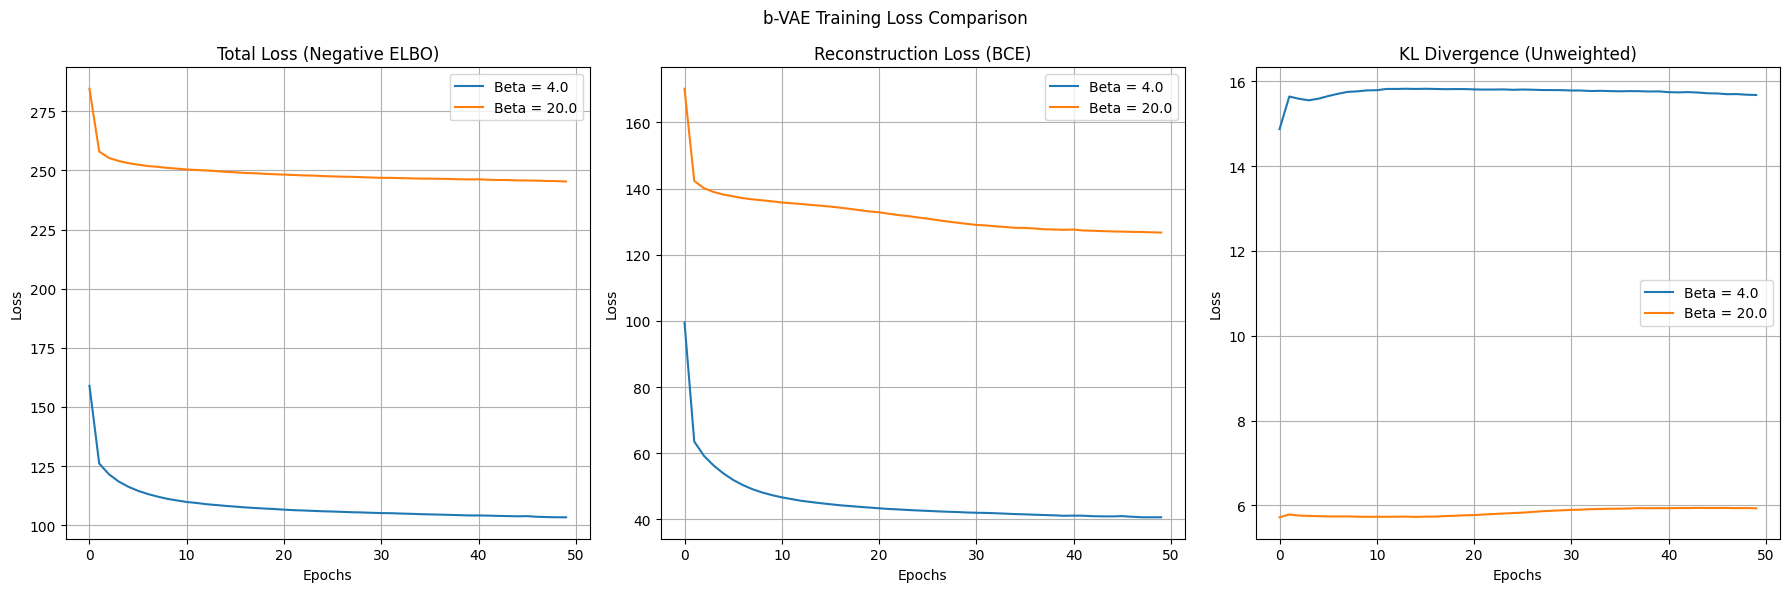

In [ ]:
plt.figure(figsize=(18, 6))

# Plot 1: Total Loss
plt.subplot(1, 3, 1)
for beta, history in all_loss_histories.items():
    plt.plot(history['total'], label=f'Beta = {beta}')
plt.title('Total Loss (Negative ELBO)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Reconstruction Loss
plt.subplot(1, 3, 2)
for beta, history in all_loss_histories.items():
    plt.plot(history['recon'], label=f'Beta = {beta}')
plt.title('Reconstruction Loss (BCE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 3: KL Divergence
plt.subplot(1, 3, 3)
for beta, history in all_loss_histories.items():
    plt.plot(history['kl'], label=f'Beta = {beta}')
plt.title('KL Divergence (Unweighted)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('b-VAE Training Loss Comparison')
plt.tight_layout()
plt.show()

In [ ]:
model_beta_low = VAE(latent_dim=LATENT_DIM).to(device)
model_beta_high = VAE(latent_dim=LATENT_DIM).to(device)

# Load the saved final weights
model_beta_low.load_state_dict(torch.load(all_final_model_paths[BETA_LOW], map_location=device))
model_beta_high.load_state_dict(torch.load(all_final_model_paths[BETA_HIGH], map_location=device))

# Set to eval mode
model_beta_low.eval()
model_beta_high.eval()

indices = np.random.randint(0, len(train_dataset), 8)
sample_images = torch.stack([train_dataset[i] for i in indices]).to(device)

with torch.no_grad():
    recon_low, _, _ = model_beta_low(sample_images)
    recon_high, _, _ = model_beta_high(sample_images)

fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(16, 6))

sample_np = sample_images.cpu().numpy().squeeze()
recon_low_np = recon_low.cpu().numpy().squeeze()
recon_high_np = recon_high.cpu().numpy().squeeze()

for i in range(8):
    # Row 1: Original
    axes[0, i].imshow(sample_np[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, 0].set_title('Original', loc='left', fontsize=10)

    # Row 2: Recon (Beta = LOW)
    axes[1, i].imshow(recon_low_np[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, 0].set_title(f'Recon (Beta={BETA_LOW})', loc='left', fontsize=10)

    # Row 3: Recon (Beta = HIGH)
    axes[2, i].imshow(recon_high_np[i], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, 0].set_title(f'Recon (Beta={BETA_HIGH})', loc='left', fontsize=10)

plt.suptitle('b-VAE Reconstruction Comparison')
plt.tight_layout()
plt.show()

#Results

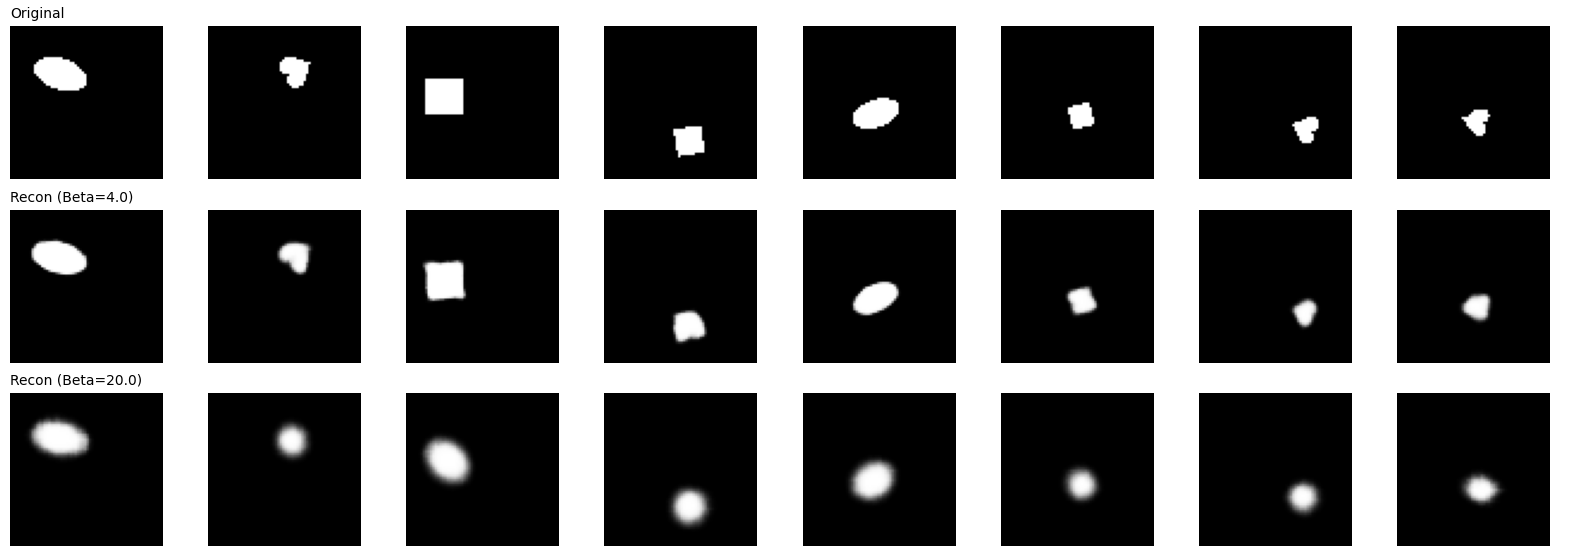

# Calculating MIG for the 3 models

Here I will load trained models from my google drive and calculate MIG for them

In [ ]:
import torch
import numpy as np
import os
from google.colab import drive
from sklearn.metrics import mutual_info_score
from torch.utils.data import DataLoader

drive.mount('/content/drive')


@torch.no_grad()
def get_latent_representations(model, dataloader, device, num_samples=20000):

    model.eval()

    all_mus = np.zeros((num_samples, LATENT_DIM), dtype=np.float32)
    all_factors = np.zeros((num_samples, 6), dtype=np.int32)

    current_idx = 0

    print("Starting efficient latent extraction...")
    for images, factors in dataloader:
        if current_idx >= num_samples:
            break

        images = images.to(device)

        _, mu, _ = model(images)

        num_to_copy = min(images.shape[0], num_samples - current_idx)

        all_mus[current_idx : current_idx + num_to_copy] = mu[:num_to_copy].cpu().numpy()
        all_factors[current_idx : current_idx + num_to_copy] = factors[:num_to_copy].numpy()

        current_idx += num_to_copy

    print(f"Extracted {current_idx} latent samples.")

    if current_idx < num_samples:
        all_mus = all_mus[:current_idx]
        all_factors = all_factors[:current_idx]

    return all_mus, all_factors

def calculate_entropy(discrete_data):

    _, counts = np.unique(discrete_data, return_counts=True)
    probabilities = counts / len(discrete_data)
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-9))
    return entropy

def calculate_mig(mus, factors, num_bins=20):

    num_latents = mus.shape[1]
    num_factors = factors.shape[1]

    discrete_mus = np.zeros_like(mus, dtype=np.int32)
    for i in range(num_latents):
        # Find bin edges for this latent dim
        bin_edges = np.histogram_bin_edges(mus[:, i], bins=num_bins)
        # Digitize: assign each value to a bin index
        discrete_mus[:, i] = np.digitize(mus[:, i], bin_edges)

    mi_matrix = np.zeros((num_latents, num_factors))
    entropies = np.zeros(num_factors)

    for k in range(num_factors):
        entropies[k] = calculate_entropy(factors[:, k])
        for i in range(num_latents):
            # Calculate MI between z_i and v_k
            mi = mutual_info_score(discrete_mus[:, i], factors[:, k])
            # Normalize by entropy
            mi_matrix[i, k] = mi / (entropies[k] + 1e-9)

    # Calculate MIG
    gaps = []

    for k in range(1, num_factors):
        # Sort the MI values for this factor (column k)
        sorted_mi_for_factor_k = np.sort(mi_matrix[:, k])

        # Get top 1 and top 2
        top_1_mi = sorted_mi_for_factor_k[-1]
        top_2_mi = sorted_mi_for_factor_k[-2]

        # Calculate the gap
        gap = top_1_mi - top_2_mi
        gaps.append(gap)

    # Final score is the mean of gaps
    overall_mig = np.mean(gaps)

    factor_gaps = {k: g for k, g in zip(range(1, num_factors), gaps)}

    return overall_mig, factor_gaps, mi_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.metrics import mutual_info_score

class MIG_DspritesDataset(Dataset):
    def __init__(self, npz_path):
        try:
            self.data = np.load(npz_path, mmap_mode='r')
            self.imgs = self.data['imgs']
            self.latents_classes = self.data['latents_classes'] # We need this for MIG
            print(f"MIG_DspritesDataset initialized. Total images: {len(self.imgs)}")
        except FileNotFoundError:
            print(f"Error: Dataset file not found at {npz_path}")
            self.imgs = None

    def __len__(self):
        if self.imgs is not None:
            return len(self.imgs)
        return 0

    def __getitem__(self, idx):
        if self.imgs is None:
            raise IndexError("Dataset not loaded correctly.")

        img = self.imgs[idx].copy()
        img_tensor = torch.from_numpy(img).float().unsqueeze(0)

        factors = self.latents_classes[idx].copy()
        factors_tensor = torch.from_numpy(factors)

        return img_tensor, factors_tensor

In [ ]:
BETA_LOW = 4.0
BETA_HIGH = 20.0
save_folder = '/content/drive/MyDrive/DGM_HW1_Results'
vae_folder_path = os.path.join(save_folder, 'VAE')
bvae_folder_path = os.path.join(save_folder, 'B-VAE')

#Create DataLoader using the NEW class
    mig_dataset = MIG_DspritesDataset(npz_path)

    mig_loader = DataLoader(
        dataset=mig_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    print("MIG DataLoader created successfully using MIG_DspritesDataset.")
except Exception as e:
    print(f"Error creating DataLoader: {e}.")

#Define models
try:
    model_vae = VAE(latent_dim=LATENT_DIM).to(device)
    model_bvae_low = VAE(latent_dim=LATENT_DIM).to(device)
    model_bvae_high = VAE(latent_dim=LATENT_DIM).to(device)
    print("Model architectures instantiated.")
except NameError:
    print("Error: 'VAE' class is not defined. Please run the cell with the VAE class definition.")

#Define paths to saved weights in Google Drive
path_vae = os.path.join(vae_folder_path, 'vae_model_state_dict.pth')
path_bvae_low = os.path.join(bvae_folder_path, f"bVAE_beta_{BETA_LOW}_FINAL.pth")
path_bvae_high = os.path.join(bvae_folder_path, f"bVAE_beta_{BETA_HIGH}_FINAL.pth")

models_to_test = {
    "VAE (Beta=1)": (model_vae, path_vae),
    f"b-VAE (Beta={BETA_LOW})": (model_bvae_low, path_bvae_low),
    f"b-VAE (Beta={BETA_HIGH})": (model_bvae_high, path_bvae_high)
}

print("Starting MIG calculation for all 3 models...")
mig_results = {}

#Main Execution Loop
if 'mig_loader' in locals():
    for model_name, (model_instance, model_path) in models_to_test.items():
        print(f"\n--- Testing Model: {model_name} ---")
        try:
            # Load the saved weights from Google Drive
            print(f"Loading weights from: {model_path}")
            model_instance.load_state_dict(torch.load(model_path, map_location=device))

            mus, factors = get_latent_representations(model_instance, mig_loader, device, num_samples=20000)

            #Calculate MIG
            overall_mig, factor_gaps, _ = calculate_mig(mus, factors)

            mig_results[model_name] = (overall_mig, factor_gaps)

            print(f"[{model_name}] Overall MIG Score: {overall_mig:.4f}")
            print("Gaps per factor (1:shape, 2:scale, 3:rot, 4:x, 5:y):")
            print(factor_gaps)

        except FileNotFoundError:
            print(f"!!! Error: Could not find model file: {model_path}. Skipping.")
            print("    Please check if the file exists in your Google Drive.")
        except Exception as e:
            print(f"An error occurred for {model_name}: {e}")

    print("\n--- Final MIG Results Comparison ---")
    for model_name, (overall_mig, _) in mig_results.items():
        print(f"{model_name:<20}: {overall_mig:.4f}")
else:
    print("MIG calculation skipped because DataLoader ('mig_loader') was not created.")

MIG_DspritesDataset initialized. Total images: 737280
MIG DataLoader created successfully using MIG_DspritesDataset.
Model architectures instantiated.
Starting MIG calculation for all 3 models...

--- Testing Model: VAE (Beta=1) ---
Loading weights from: /content/drive/MyDrive/DGM_HW1_Results/VAE/vae_model_state_dict.pth
Starting efficient latent extraction...
Extracted 20000 latent samples.
[VAE (Beta=1)] Overall MIG Score: 0.0241
Gaps per factor (1:shape, 2:scale, 3:rot, 4:x, 5:y):
{1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.014095361152211008), 4: np.float64(0.09669824270305988), 5: np.float64(0.009582967848918045)}

--- Testing Model: b-VAE (Beta=4.0) ---
Loading weights from: /content/drive/MyDrive/DGM_HW1_Results/B-VAE/bVAE_beta_4.0_FINAL.pth
Starting efficient latent extraction...
Extracted 20000 latent samples.
[b-VAE (Beta=4.0)] Overall MIG Score: 0.0250
Gaps per factor (1:shape, 2:scale, 3:rot, 4:x, 5:y):
{1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0

#Representing Latent Space Using PCA

In [ ]:
folder_path = '/content/drive/MyDrive/dsprites_dataset'
npz_path = os.path.join(folder_path, 'dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz')

LATENT_DIM = 32
BETA_HIGH = 20.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Defined npz_path: {npz_path}")
print(f"Defined LATENT_DIM: {LATENT_DIM}")
print(f"Defined BETA_HIGH: {BETA_HIGH}")
print(f"Defined device: {device}")

Defined npz_path: /content/drive/MyDrive/dsprites_dataset/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz
Defined LATENT_DIM: 32
Defined BETA_HIGH: 20.0
Defined device: cuda


Successfully loaded model: /content/drive/MyDrive/DGM_HW1_Results/B-VAE/bVAE_beta_20.0_FINAL.pth
MIG_DspritesDataset initialized. Total images: 737280
DataLoader for PCA created.
Extracting latent representations...
Starting efficient latent extraction...
Extracted 20000 latent samples.
Extracted mus shape: (20000, 32), factors shape: (20000, 6)
Applying PCA...
PCA components shape: (20000, 2)


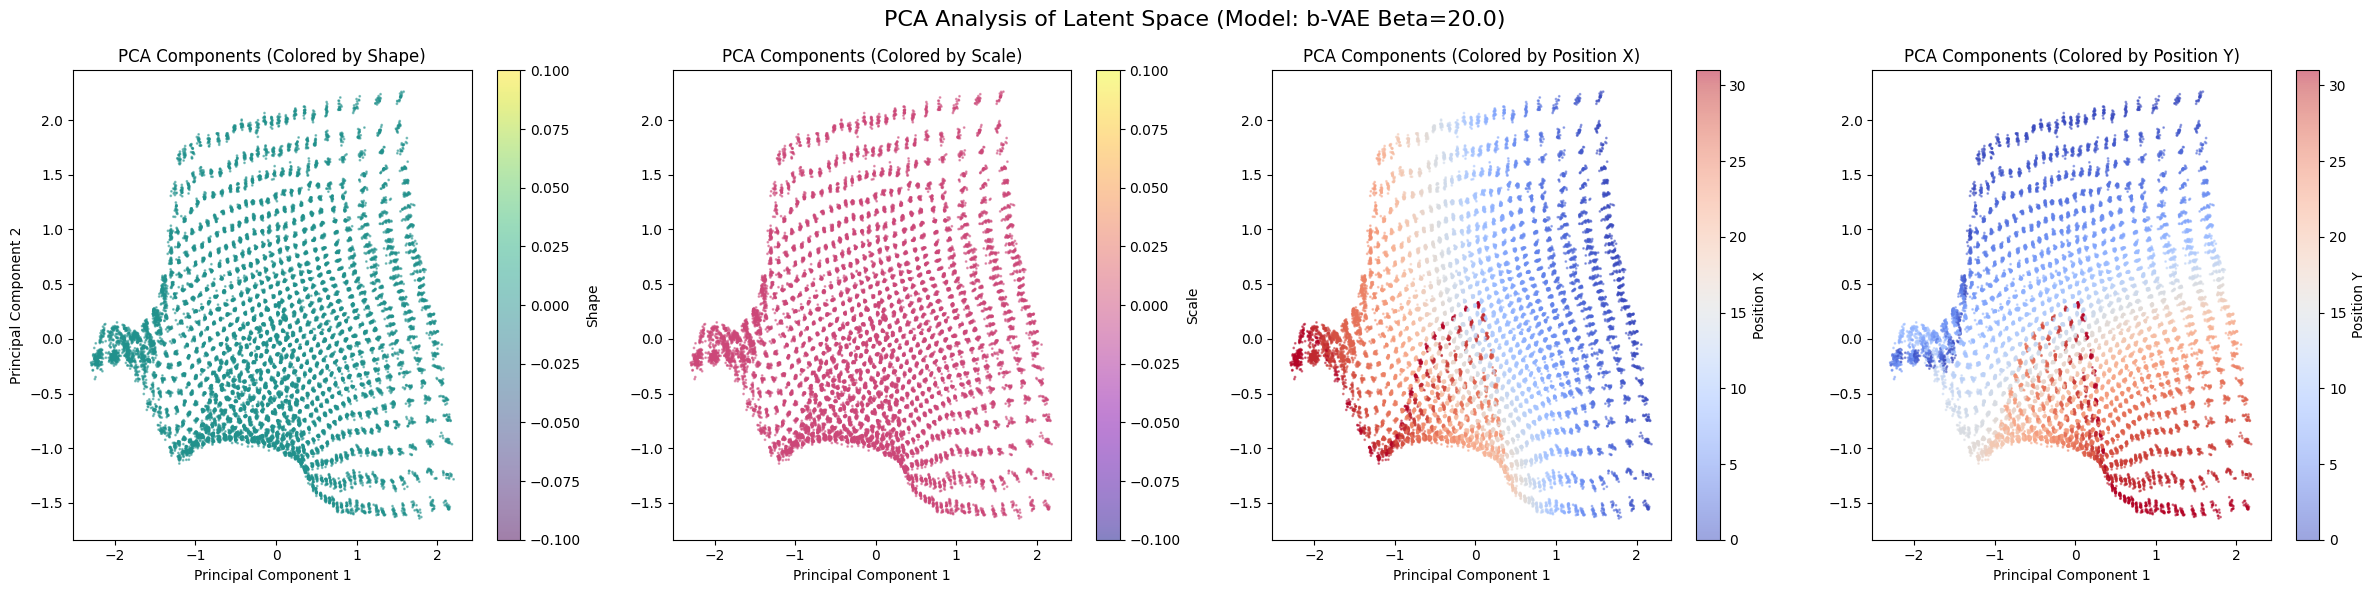

In [ ]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import drive

BETA_HIGH = 20.0

gdrive_base_path = '/content/drive/MyDrive/DGM_HW1_Results'
bvae_folder_path = os.path.join(gdrive_base_path, 'B-VAE')

#Load the High-Beta Model
model_to_analyze = VAE(latent_dim=LATENT_DIM).to(device)
model_path = os.path.join(bvae_folder_path, f"bVAE_beta_{BETA_HIGH}_FINAL.pth")

try:
    model_to_analyze.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Successfully loaded model: {model_path}")
except FileNotFoundError:
    print(f"!!! Error: Model file not found at {model_path}")
except Exception as e:
    print(f"Error loading model: {e}")

#Create DataLoader
try:
    pca_dataset = MIG_DspritesDataset(npz_path)
    pca_loader = DataLoader(
        dataset=pca_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    print("DataLoader for PCA created.")
except Exception as e:
    print(f"Error creating DataLoader: {e}")

#Get Latent Representations
try:
    print("Extracting latent representations...")
    mus, factors = get_latent_representations(model_to_analyze, pca_loader, device, num_samples=20000)
    print(f"Extracted mus shape: {mus.shape}, factors shape: {factors.shape}")
except Exception as e:
    print(f"Error during latent extraction: {e}")


#Apply PCA
try:
    print("Applying PCA...")
    pca = PCA(n_components=2)
    # Fit PCA on the latent representations (mus)
    pca_components = pca.fit_transform(mus)
    print(f"PCA components shape: {pca_components.shape}")

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    factor_names = {
        1: 'Shape',
        2: 'Scale',
        4: 'Position X',
        5: 'Position Y'
    }

    #Colored by Shape (Factor 1)
    ax = axes[0]
    sc = ax.scatter(pca_components[:, 0], pca_components[:, 1], c=factors[:, 1], cmap='viridis', s=1, alpha=0.5)
    ax.set_title('PCA Components (Colored by Shape)')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    fig.colorbar(sc, ax=ax, label='Shape')

    #Colored by Scale (Factor 2)
    ax = axes[1]
    sc = ax.scatter(pca_components[:, 0], pca_components[:, 1], c=factors[:, 2], cmap='plasma', s=1, alpha=0.5)
    ax.set_title('PCA Components (Colored by Scale)')
    ax.set_xlabel('Principal Component 1')
    fig.colorbar(sc, ax=ax, label='Scale')

    #Colored by Position X (Factor 4)
    ax = axes[2]
    sc = ax.scatter(pca_components[:, 0], pca_components[:, 1], c=factors[:, 4], cmap='coolwarm', s=1, alpha=0.5)
    ax.set_title('PCA Components (Colored by Position X)')
    ax.set_xlabel('Principal Component 1')
    fig.colorbar(sc, ax=ax, label='Position X')

    #Colored by Position Y (Factor 5)
    ax = axes[3]
    sc = ax.scatter(pca_components[:, 0], pca_components[:, 1], c=factors[:, 5], cmap='coolwarm', s=1, alpha=0.5)
    ax.set_title('PCA Components (Colored by Position Y)')
    ax.set_xlabel('Principal Component 1')
    fig.colorbar(sc, ax=ax, label='Position Y')

    plt.suptitle(f'PCA Analysis of Latent Space (Model: b-VAE Beta={BETA_HIGH})', fontsize=16)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error during PCA or plotting: {e}")